In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

from importlib import reload
import numpy as np

In [3]:
from pathlib import Path

SAVE_FIG_PATH = Path("../results/figures/main")

In [ ]:
from GridMaze.analysis.behaviour import learning as bl

learning_df = bl.get_learning_curve_df()
expert_df = bl.get_expert_performance_df()

Learning stats:
                  Mixed Linear Model Regression Results
Model:                  MixedLM      Dependent Variable:      total_trials
No. Observations:       135          Method:                  ML          
No. Groups:             15           Scale:                   259.5240    
Min. group size:        9            Log-Likelihood:          -582.9639   
Max. group size:        9            Converged:               Yes         
Mean group size:        9.0                                               
--------------------------------------------------------------------------
                               Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------------
Intercept                      26.569    6.686  3.974 0.000  13.464 39.675
condition[T.opto]              -3.887    9.788 -0.397 0.691 -23.071 15.297
day_on_maze                     8.667    0.735 11.786 0.000   7.225 10.108
condition[T.opto]:day_on_maz

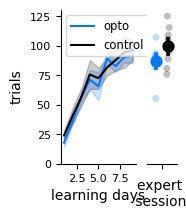

In [15]:
reload(bl)
fig, axes = plt.subplots(1, 2, figsize=(1.5, 2), width_ratios=[1, 0.4], sharey=True)
bl.plot_performance_summary(learning_df, expert_df, maze_order=1, print_stats=True, axes=axes)
fig.savefig(SAVE_FIG_PATH / "opto_trials.pdf")

In [19]:
from GridMaze.analysis.behaviour import performance_metrics as pm
from GridMaze.analysis.core import plotting as cp

performance_df = pm.get_performance_df()

Mixed ANOVA: n_excess_steps
+-------------+----------+-------+-------+----------+----------+-------------+----------+-------+
| Source      |       SS |   DF1 |   DF2 |       MS |        F |       p-unc |      np2 |   eps |
|-------------+----------+-------+-------+----------+----------+-------------+----------+-------|
| condition   | 10.6708  |     1 |    13 | 10.6708  |  6.40357 | 0.0250999   | 0.33002  |   nan |
| stim_trial  |  4.77945 |     1 |    13 |  4.77945 | 35.0844  | 5.04046e-05 | 0.729642 |     1 |
| Interaction |  2.16722 |     1 |    13 |  2.16722 | 15.9088  | 0.00154493  | 0.55031  |   nan |
+-------------+----------+-------+-------+----------+----------+-------------+----------+-------+


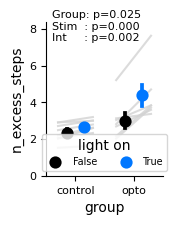

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
pm.plot_random_effects_summary(
    performance_df,
    y="n_excess_steps",
    stim_day_range=(6, np.inf),
    print_stats=True,
    ax=ax,
)
fig.savefig(SAVE_FIG_PATH / "exess_steps.pdf")

In [17]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

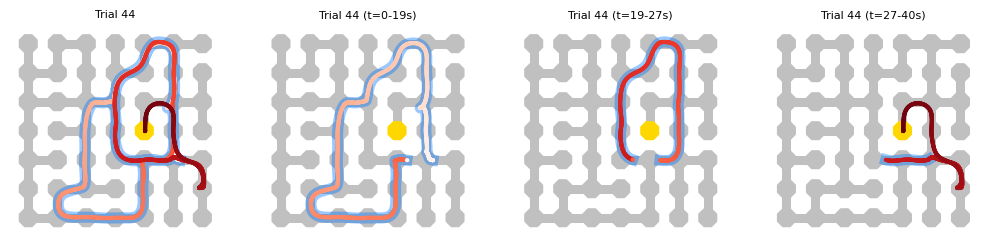

In [18]:
# example session (opto subject)
session = gs.get_maze_sessions(subject_IDs=["mFC-opto_26"], total_stim_days=[17], with_data=["navigation_df"])[0]

# example trial
trial = 44
f, axes = plt.subplots(1, 4, figsize=(12.5, 3.5))
for ax, t_range in zip(axes, [None, (0, 19), (19, 27), (27, 40)]):
    tp.plot_fancy_trial_trajectory(session, trial=trial, t_range=t_range, ax=ax)
f.savefig(SAVE_FIG_PATH / "opto_trajectory.pdf")

In [9]:
from GridMaze.analysis.errors import errors

error_df = errors.get_error_df()

Mixed ANOVA: repeat_error_rate
+-------------+-------------+-------+-------+-------------+----------+------------+----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |      p-unc |      np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+------------+----------+-------|
| condition   | 1.43707e-06 |     1 |    13 | 1.43707e-06 |  5.69083 | 0.0329644  | 0.304472 |   nan |
| stim_trial  | 1.75519e-06 |     1 |    13 | 1.75519e-06 | 10.2661  | 0.00691314 | 0.441247 |     1 |
| Interaction | 1.18822e-06 |     1 |    13 | 1.18822e-06 |  6.94987 | 0.0205415  | 0.348367 |   nan |
+-------------+-------------+-------+-------+-------------+----------+------------+----------+-------+


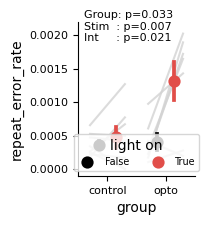

In [46]:
reload(errors)
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
errors.plot_group_by_stim_errors(
    error_df,
    e="repeat_error",
    stim_color="#E14E49",
    stim_day_range=None,
    ax=ax,
    print_stats=True,
    legend=True,
)
ax.set_ylim(-0.0001, 0.0022)
fig.savefig(SAVE_FIG_PATH / "repeat_errors.pdf")

In [14]:
from GridMaze.analysis.errors import correction as corr

reload(corr)

<module 'GridMaze.analysis.errors.correction' from '/ceph/behrens/peter_doohan/goalNav_opto-mFC/route_planning/code/GridMaze/analysis/errors/correction.py'>

In [15]:
results_df = corr.get_error_centered_df(
    error_df,
    n_jobs=-1,
)

In [ ]:
import pandas as pd

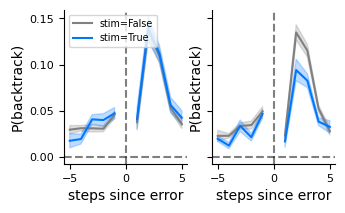

In [49]:
reload(corr)
fig, axes = plt.subplots(1, 2, figsize=(3.5, 2), sharex=True, sharey=True)
corr.plot_prob_backtrack_after_error(results_df, axes=axes)
fig.savefig(SAVE_FIG_PATH / "prob_backtrack_after_error.pdf")

Mixed ANOVA: prob_backtrack
+-------------+------------+-------+-------+------------+----------+------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |      p-unc |      np2 |   eps |
|-------------+------------+-------+-------+------------+----------+------------+----------+-------|
| condition   | 0.00236122 |     1 |    13 | 0.00236122 | 11.4477  | 0.00489566 | 0.468252 |   nan |
| stim_trial  | 0.00182034 |     1 |    13 | 0.00182034 |  6.93627 | 0.0206425  | 0.347922 |     1 |
| Interaction | 0.00292567 |     1 |    13 | 0.00292567 | 11.1481  | 0.00533365 | 0.461654 |   nan |
+-------------+------------+-------+-------+------------+----------+------------+----------+-------+


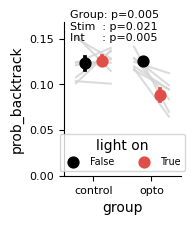

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(1.5, 2))
corr.plot_group_by_stim_error_backtrack(results_df, stim_color="#E14E49", ax=ax)
fig.savefig(SAVE_FIG_PATH / "summary_error_backtracking.pdf")

In [50]:
from GridMaze.analysis.behaviour import distance_to_goal as dtg

ddtg_df = dtg.get_delta_distance_to_goal_df()

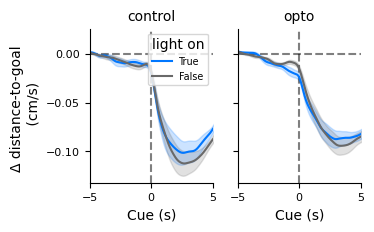

In [53]:
f, axes = plt.subplots(1, 2, figsize=(3.5, 2), sharey=True)
dtg.plot_delta_distance_to_goal_summary(ddtg_df, stim_day_range=(6, np.inf), axes=axes)
f.savefig(SAVE_FIG_PATH / "delta_distance_to_goal.pdf")

In [ ]:
from GridMaze.analysis.strategies import get_input_data as gid
from GridMaze.analysis.strategies import psychometrics as psy
from GridMaze.analysis.strategies import comparisons as com

navigation_strategies_df = gid.get_navigation_strategies_df(
    n_history=1,
    verbose=False,
)

[H≠S: habit != structure]: kept 40988/124788 decisions (32.8%)
Mixed ANOVA: prob_correct
+-------------+-----------+-------+-------+-----------+---------+-------------+----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |       F |       p-unc |      np2 |   eps |
|-------------+-----------+-------+-------+-----------+---------+-------------+----------+-------|
| condition   | 0.033982  |     1 |    13 | 0.033982  | 10.966  | 0.00562205  | 0.457564 |   nan |
| stim_trial  | 0.0463051 |     1 |    13 | 0.0463051 | 60.5598 | 3.02195e-06 | 0.823273 |     1 |
| Interaction | 0.0142317 |     1 |    13 | 0.0142317 | 18.6128 | 0.000840771 | 0.588775 |   nan |
+-------------+-----------+-------+-------+-----------+---------+-------------+----------+-------+
[V≠S: vector != structure]: kept 25688/124788 decisions (20.6%)
Mixed ANOVA: prob_correct
+-------------+-------------+-------+-------+-------------+-----------+------------+------------+-------+
| Source      |       

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
3-way mixed ANOVA (condition × stim_trial × scenario, lmer, Type III, Satterthwaite df):
+-------------------------------+------------+------------+---------+-----------+-----------+-------------+-------+
|                               |         SS |         MS |   NumDF |   DenomDF |    F-stat |       P-val | Sig   |
|-------------------------------+------------+------------+---------+-----------+-----------+-------------+-------|
| condition                     | 0.0082721  | 0.0082721  |       1 |        13 |   8.44215 | 0.0122767   | *     |
| stim_trial                    | 0.0807695  | 0.0807695  |       1 |        65 |  82.4299  | 3.59536e-13 | ***   |
| scenario                      | 1.52322    | 0.761611   |       2 |        65 | 777.268   | 4.11615e-46 | ***   |
| condition:stim_trial          | 0.013925   | 0.013925

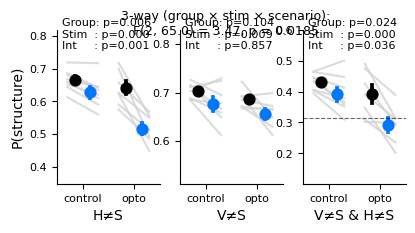

In [6]:
reload(com)
f, axes = plt.subplots(1, 3, figsize=(4.5, 2))
com.plot_prop_across_scenarios(navigation_strategies_df, decision_point_filter="only", axes=axes)
f.savefig(SAVE_FIG_PATH / "group_x_stim_strategy_comparisons.pdf")

[H=S: habit == structure]: kept 83800/124788 decisions (67.2%)
Mixed ANOVA: prob_correct
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |     p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------|
| condition   | 0.000173681 |     1 |    13 | 0.000173681 | 0.319308 | 0.581644  | 0.0239734 |   nan |
| stim_trial  | 6.41434e-05 |     1 |    13 | 6.41434e-05 | 0.698134 | 0.418504  | 0.0509656 |     1 |
| Interaction | 0.000499522 |     1 |    13 | 0.000499522 | 5.43677  | 0.0364482 | 0.294887  |   nan |
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
[H≠S: habit != structure]: kept 40988/124788 decisions (32.8%)
Mixed ANOVA: prob_correct
+-------------+-----------+-------+-------+-----------+---------+-------------+----------+-------+
| 

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
3-way mixed ANOVA (condition × stim_trial × scenario, lmer, Type III, Satterthwaite df):
+-------------------------------+------------+------------+---------+-----------+------------+-------------+-------+
|                               |         SS |         MS |   NumDF |   DenomDF |     F-stat |       P-val | Sig   |
|-------------------------------+------------+------------+---------+-----------+------------+-------------+-------|
| condition                     | 0.00508865 | 0.00508865 |       1 |        13 |    7.72861 | 0.0156149   | *     |
| stim_trial                    | 0.0262575  | 0.0262575  |       1 |        39 |   39.8798  | 1.89161e-07 | ***   |
| scenario                      | 1.02465    | 1.02465    |       1 |        39 | 1556.23    | 4.78007e-33 | ***   |
| condition:stim_trial          | 0.00469933 | 0.

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
3-way mixed ANOVA (condition × stim_trial × scenario, lmer, Type III, Satterthwaite df):
+-------------------------------+-------------+-------------+---------+-----------+------------+-------------+-------+
|                               |          SS |          MS |   NumDF |   DenomDF |     F-stat |       P-val | Sig   |
|-------------------------------+-------------+-------------+---------+-----------+------------+-------------+-------|
| condition                     | 0.00241521  | 0.00241521  |       1 |        13 |   5.77089  | 0.0319491   | *     |
| stim_trial                    | 0.0142995   | 0.0142995   |       1 |        39 |  34.1672   | 8.4954e-07  | ***   |
| scenario                      | 0.266912    | 0.266912    |       1 |        39 | 637.758    | 8.87524e-26 | ***   |
| condition:stim_trial          | 0.0

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


SS Type III Analysis of Variance Table with Satterthwaite approximated degrees of freedom:
(NOTE: Using original model contrasts, orthogonality not guaranteed)
3-way mixed ANOVA (condition × stim_trial × scenario, lmer, Type III, Satterthwaite df):
+-------------------------------+------------+------------+---------+-----------+------------+-------------+-------+
|                               |         SS |         MS |   NumDF |   DenomDF |     F-stat |       P-val | Sig   |
|-------------------------------+------------+------------+---------+-----------+------------+-------------+-------|
| condition                     | 0.00725576 | 0.00725576 |       1 |        13 |    6.01334 | 0.0290918   | *     |
| stim_trial                    | 0.0199819  | 0.0199819  |       1 |        39 |   16.5604  | 0.000222384 | ***   |
| scenario                      | 3.97657    | 3.97657    |       1 |        39 | 3295.65    | 2.70601e-39 | ***   |
| condition:stim_trial          | 0.00237666 | 0.

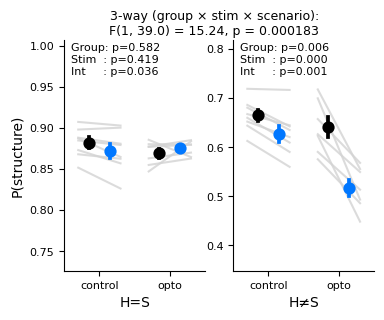

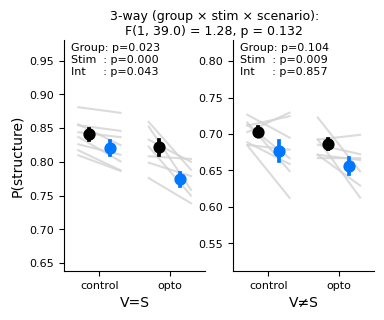

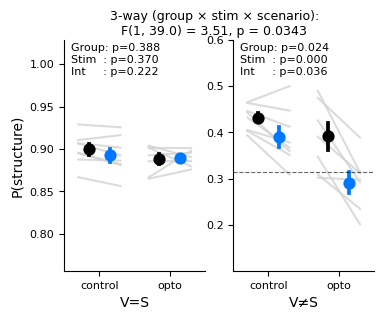

In [ ]:
# for 3-way stats:
com.plot_prop_across_scenarios(
    navigation_strategies_df,
    scenarios={
        "H=S": ("habit == structure",),
        "H≠S": ("habit != structure",),
    },
    decision_point_filter="only",
)

com.plot_prop_across_scenarios(
    navigation_strategies_df,
    scenarios={
        "V=S": ("vector == structure",),
        "V≠S": ("vector != structure",),
    },
    decision_point_filter="only",
)

com.plot_prop_across_scenarios(
    navigation_strategies_df,
    scenarios={
        "V=S": ("vector == structure", "habit == structure"),
        "V≠S": ("vector != structure", "habit != structure"),
    },
    decision_point_filter="only",
)

In [24]:
from GridMaze.analysis.strategies import opto_effects as oe

Mixed ANOVA: vector
+-------------+------------+-------+-------+------------+----------+-----------+-----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |     p-unc |       np2 |   eps |
|-------------+------------+-------+-------+------------+----------+-----------+-----------+-------|
| condition   | 0.0273213  |     1 |    13 | 0.0273213  | 0.781644 | 0.392697  | 0.0567163 |   nan |
| stim_trial  | 0.0236307  |     1 |    13 | 0.0236307  | 5.25982  | 0.0391328 | 0.288054  |     1 |
| Interaction | 0.00112907 |     1 |    13 | 0.00112907 | 0.251313 | 0.624534  | 0.0189651 |   nan |
+-------------+------------+-------+-------+------------+----------+-----------+-----------+-------+
Mixed ANOVA: structure
+-------------+------------+-------+-------+------------+----------+----------+-----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |    p-unc |       np2 |   eps |
|-------------+------------+-------+-------+------

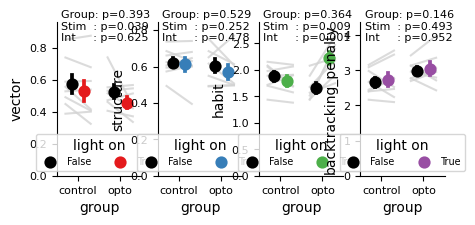

In [87]:
strategies = ["vector", "structure", "habit", "backtracking_penalty"]
results_df = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df[navigation_strategies_df.maze_name == "maze_1"],
    strategies=strategies,
    stim_day_range=(4, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(1.25 * len(strategies), 2))
oe.plot_mixture_of_strategy_weights(results_df, axes=axes, cmap="Set1", print_stats=True)
fig.savefig(SAVE_FIG_PATH / "strategy_weights_maze_1.pdf")

Mixed ANOVA: vector
+-------------+-----------+-------+-------+-----------+-------------+-----------+-------------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |           F |     p-unc |         np2 |   eps |
|-------------+-----------+-------+-------+-----------+-------------+-----------+-------------+-------|
| condition   | 0.129151  |     1 |    13 | 0.129151  | 4.29405     | 0.0586949 | 0.248296    |   nan |
| stim_trial  | 0.0211791 |     1 |    13 | 0.0211791 | 1.96999     | 0.183883  | 0.131596    |     1 |
| Interaction | 9.522e-07 |     1 |    13 | 9.522e-07 | 8.85694e-05 | 0.992634  | 6.81299e-06 |   nan |
+-------------+-----------+-------+-------+-----------+-------------+-----------+-------------+-------+
Mixed ANOVA: structure
+-------------+------------+-------+-------+------------+----------+------------+----------+-------+
| Source      |         SS |   DF1 |   DF2 |         MS |        F |      p-unc |      np2 |   eps |
|-------------+------------

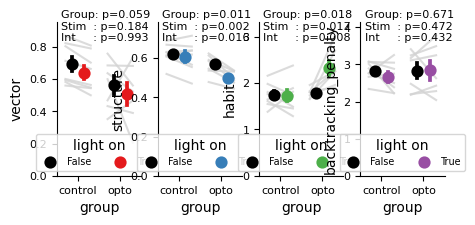

In [89]:
strategies = ["vector", "structure", "habit", "backtracking_penalty"]
results_df2 = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df[navigation_strategies_df.maze_name == "maze_2"],
    strategies=strategies,
    stim_day_range=(4, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(1.25 * len(strategies), 2))
oe.plot_mixture_of_strategy_weights(results_df2, axes=axes, cmap="Set1", print_stats=True)
fig.savefig(SAVE_FIG_PATH / "strategy_weights_maze_2.pdf")

Mixed ANOVA: vector
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |        F |     p-unc |       np2 |   eps |
|-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------|
| condition   | 0.0255744   |     1 |    13 | 0.0255744   | 0.795706 | 0.388593  | 0.0576778 |   nan |
| stim_trial  | 0.0163022   |     1 |    13 | 0.0163022   | 3.58651  | 0.0807175 | 0.216231  |     1 |
| Interaction | 0.000717953 |     1 |    13 | 0.000717953 | 0.157951 | 0.697499  | 0.0120042 |   nan |
+-------------+-------------+-------+-------+-------------+----------+-----------+-----------+-------+
Mixed ANOVA: structure_close
+-------------+-----------+-------+-------+-----------+---------+-----------+----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |       F |     p-unc |      np2 |   eps |
|-------------+-----------+-------+-

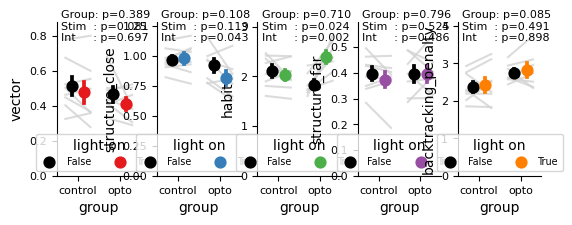

In [90]:
strategies = ["vector", "structure_close", "habit", "structure_far", "backtracking_penalty"]
results_df = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df[navigation_strategies_df.maze_name == "maze_1"],
    strategies=strategies,
    stim_day_range=(4, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(1.25 * len(strategies), 2))
oe.plot_mixture_of_strategy_weights(results_df, axes=axes, cmap="Set1", print_stats=True)

Mixed ANOVA: vector
+-------------+-------------+-------+-------+-------------+-----------+----------+------------+-------+
| Source      |          SS |   DF1 |   DF2 |          MS |         F |    p-unc |        np2 |   eps |
|-------------+-------------+-------+-------+-------------+-----------+----------+------------+-------|
| condition   | 0.0860597   |     1 |    13 | 0.0860597   | 2.75255   | 0.121017 | 0.174737   |   nan |
| stim_trial  | 0.0145493   |     1 |    13 | 0.0145493   | 1.20722   | 0.291816 | 0.0849724  |     1 |
| Interaction | 0.000574439 |     1 |    13 | 0.000574439 | 0.0476639 | 0.830569 | 0.00365306 |   nan |
+-------------+-------------+-------+-------+-------------+-----------+----------+------------+-------+
Mixed ANOVA: structure_close
+-------------+-----------+-------+-------+-----------+----------+-------------+----------+-------+
| Source      |        SS |   DF1 |   DF2 |        MS |        F |       p-unc |      np2 |   eps |
|-------------+--------

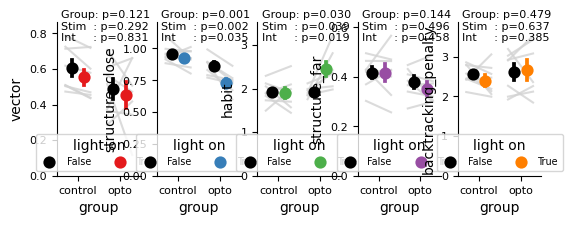

In [91]:
strategies = ["vector", "structure_close", "habit", "structure_far", "backtracking_penalty"]
results_df = oe.get_group_by_stim_strategy_weights(
    navigation_strategies_df[navigation_strategies_df.maze_name == "maze_2"],
    strategies=strategies,
    stim_day_range=(4, np.inf),
    max_trial_duration=None,
    stim_only=False,
)
fig, axes = plt.subplots(1, len(strategies), figsize=(1.25 * len(strategies), 2))
oe.plot_mixture_of_strategy_weights(results_df, axes=axes, cmap="Set1", print_stats=True)